In [91]:
from dotenv import load_dotenv
from pydantic import BaseModel
import re
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langchain_core.documents import Document
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_chroma import Chroma
import os

In [92]:
# client = chromadb.HttpClient(host="localhost", port=8000, ssl=False)


embeddings = MistralAIEmbeddings(model="mistral-embed")

vector_store = Chroma(
    collection_name="example",
    embedding_function=embeddings,
    chroma_cloud_api_key=os.getenv("CHROMA_API_KEY"),
    tenant=os.getenv("CHROMA_TENANT"),
    database=os.getenv("CHROMA_DATABASE"),
)

In [93]:
llm = ChatMistralAI(model="mistral-large-latest")

In [94]:
docs = (
    PyPDFLoader('thebook.pdf').load()
)

In [95]:


chunks = RecursiveCharacterTextSplitter(chunk_size=2100, chunk_overlap=500).split_documents(docs)


clean_chunks = [
    d for d in chunks
    if isinstance(d.page_content, str) and d.page_content.strip() != ""
]

In [96]:

# add documents (only once)
if len(vector_store.get()["documents"]) == 0:
    vector_store.add_documents(clean_chunks)
    print("Documents added")
else:
    print("Already exists")

Already exists


In [97]:
retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":4,
        "fetch_k": 20,
        "lambda_mult": 0.7
    }
)

In [98]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [99]:
class State(TypedDict):
    question: str
    docs: list[Document]
    good_docs: list[Document]
    verdict: str
    reason: str

    strips: list[str]
    kept_strips: list[str]
    refined_context: str
    web_query: str
    web_docs: list[Document]
    answer: str

In [100]:
def retriever_node(state: State):
    q = state['question']
    return {"docs": retriever.invoke(q)}

In [101]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------

class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)


doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


def eval_each_doc_node(state: State) -> State:
    q = state['question']
    scores: list[float] = []
    good: list[Document] = []

    for d in state['docs']:
        out = doc_eval_chain.invoke({'question': q, 'chunk': d.page_content})
        scores.append(out.score)

        # keep any doc above lower_th as "weakly relevent"
        if out.score > LOWER_TH:
            good.append(d)

    # CORRECT at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }
    
    # INCORRECT all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }
    

    # AMBIGUOUS otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }


In [102]:
def decompose_to_sentences(text: str) -> list[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


class keepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(keepOrDrop)


# -----------------------------
# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------



def refine(state: State) -> State:
    q = state['question']

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: list[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [103]:
# Query rewrite for web search

class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)



rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}



# Web search node

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State) -> State:
    q = state["web_query"] or state["question"]
    results = tavily.invoke({"query": q})

    web_docs: list[Document] = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}



In [104]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state: State) -> str:
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["refined_context"]})
    return { "answer": out.content}

In [105]:
# -----------------------------
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else: 
        return "rewrite_query"

In [ ]:
# Build Graph

g = StateGraph(State)

g.add_node("retriever", retriever_node)
g.add_node("eval_each_doc_node", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retriever")
g.add_edge("retriever", "eval_each_doc_node")

g.add_conditional_edges(
    "eval_each_doc_node",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

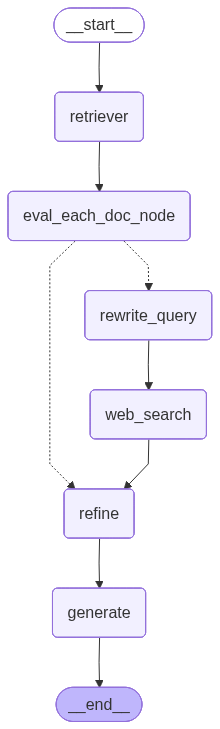

In [107]:
app

In [108]:
# -----------------------------
# Run example
# -----------------------------
res = app.invoke(
    {
        "question": "What is machine learning",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",
    }
)

In [109]:
res

{'question': 'What is machine learning',
 'docs': [Document(id='9d73d1a2-f087-4e54-940a-f247e24a6b0d', metadata={'subject': '', 'creationdate': '2010-10-01T15:47:05-07:00', 'producer': 'pdfTeX-1.40.10', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea version 5.0.0', 'title': 'AnIntroductiontoMachineLearning', 'author': 'AlexJ.SmolaandVishyS.V.N.Vishwanathan', 'total_pages': 234, 'page_label': 'i', 'creator': 'LaTeX with hyperref package', 'moddate': '2010-10-01T15:47:05-07:00', 'source': 'thebook.pdf', 'keywords': '', 'page': 0}, page_content='INTRODUCTION TO MACHINE LEARNING'),
  Document(id='fea0447f-dd51-4b3e-b17c-3376ceaec263', metadata={'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea version 5.0.0', 'source': 'thebook.pdf', 'moddate': '2010-10-01T15:47:05-07:00', 'creationdate': '2010-10-01T15:47:05-07:00', 'keywords': '', 'creator':